In [1]:
# =============================================================================
# Notebook 10b — DAL sweep W&B inspection
# Compares: HA-only baseline vs HA+DAL for GAP and CLS pooling
# =============================================================================

# ── CELL 1 — Imports
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wandb
warnings.filterwarnings("ignore")
%matplotlib inline

# ── CELL 2 — Config
WANDB_LINK      = "choekyel-nyungmartsang-university-of-bern/master-thesis-mel-nv"
SAVE_FIGURES    = False
FIGURE_DPI      = 150
OUT_PREFIX      = "dal_sweep"
OUT_DIR         = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

# Filter to DAL sweep runs only
RUN_NAME_PREFIX = "sweep_dal__"

COLORS = {
    "gap": "steelblue",
    "cls": "darkorange",
}
MARKERS = {
    "gap": "o",
    "cls": "s",
}
POOLING_LABELS = {
    "gap": "GAP (mean) pooling",
    "cls": "CLS pooling",
}

TABLE_METRICS = [
    ("val_auc_roc",       "Val AUC-ROC"),
    ("val_balanced_acc",  "Val Bal.Acc"),
    ("val_ha_dice",       "Val HA-Dice"),
    ("val_inside_minus",  "Val Inside-Δ"),
    ("val_dal_loss",      "Val DAL-Loss"),
    ("test_auc_roc",      "Test AUC-ROC"),
    ("test_ha_dice",      "Test HA-Dice"),
    ("test_inside_minus", "Test Inside-Δ"),
]

# ── CELL 3 — Parse helpers
def parse_dal_lambda_from_name(name: str):
    # Matches: ...dall0p0... or ...dall5p0... etc.
    match = re.search(r"dall([0-9]+p[0-9]+)", name)
    if match is None:
        return None
    return float(match.group(1).replace("p", "."))

def parse_pooling_key_from_name(name: str):
    # Matches: sweep_dal__gap__ or sweep_dal__cls__
    # or:      sweep_dalonly__gap__ or sweep_dalonly__cls__
    match = re.search(r"__(gap|cls)__", name)
    if match is None:
        return None
    return match.group(1)

# ── CELL 4 — Pull runs from W&B
def pull_dal_runs(link: str, prefix: str) -> pd.DataFrame:
    api = wandb.Api()
    runs = api.runs(link)
    records = []
    skipped = []

    for run in runs:
        if run.state != "finished":
            skipped.append((run.name, f"state={run.state}"))
            continue
        if prefix and not run.name.startswith(prefix):
            skipped.append((run.name, "prefix mismatch"))
            continue
        # Guard: sweep_dal__ must not accidentally match sweep_dalonly__
        if prefix == "sweep_dal__" and run.name.startswith("sweep_dalonly__"):
            skipped.append((run.name, "dalonly run excluded from dal__ pull"))
            continue

        name       = run.name
        pooling    = parse_pooling_key_from_name(name)
        dal_lambda = parse_dal_lambda_from_name(name)
        # ... rest unchanged

        # Fall back to config if regex fails
        if pooling is None:
            raw = run.config.get("pooling", "")
            pooling = "gap" if raw == "mean" else raw
        if dal_lambda is None:
            dal_lambda = run.config.get("dal_lambda")

        if pooling not in ("gap", "cls"):
            skipped.append((name, f"pooling unresolved: {pooling}"))
            continue
        if dal_lambda is None:
            skipped.append((name, "dal_lambda missing"))
            continue
        try:
            dal_lambda = float(dal_lambda)
        except Exception:
            skipped.append((name, "dal_lambda not numeric"))
            continue

        s = run.summary._json_dict
        records.append({
            "run_name":          name,
            "run_id":            run.id,
            "run_url":           run.url,
            "pooling":           pooling,
            "dal_lambda":        dal_lambda,
            "ha_lambda":         run.config.get("ha_lambda", 5.0),
            # Val classification
            "val_auc_roc":       s.get("val/auc_roc"),
            "val_balanced_acc":  s.get("val/balanced_accuracy"),
            "val_recall":        s.get("val/recall_macro"),
            "val_loss":          s.get("val/loss"),
            # Val alignment
            "val_ha_dice":       s.get("val/ha_dice"),
            "val_inside_minus":  s.get("val/inside_minus_area_baseline"),
            "val_inside_frac":   s.get("val/inside_cam_fraction"),
            "val_outside_dens":  s.get("val/outside_density"),
            "val_cam_nz_frac":   s.get("val/cam_nonzero_fraction"),
            # Val DAL
            "val_dal_loss":      s.get("val/dal_loss"),
            # Test
            "test_auc_roc":      s.get("test/auc_roc"),
            "test_balanced_acc": s.get("test/balanced_accuracy"),
            "test_ha_dice":      s.get("test/ha_dice"),
            "test_inside_minus": s.get("test/inside_minus_area_baseline"),
            # Train losses
            "train_dal_loss":    s.get("train/dal_loss"),
            "train_ha_loss":     s.get("train/ha_loss"),
            "train_cls_loss":    s.get("train/cls_loss"),
        })

    if skipped:
        print(f"Skipped {len(skipped)} runs:")
        for n, r in skipped[:15]:
            print(f"  {r:>25} | {n}")
        if len(skipped) > 15:
            print(f"  ... and {len(skipped) - 15} more")

    df = pd.DataFrame(records)
    if df.empty:
        return df
    df = df.sort_values(["pooling", "dal_lambda"]).reset_index(drop=True)
    return df

In [ ]:
# ── CELL 5 — Load
api = wandb.Api()
print("Viewer:", api.viewer)

df = pull_dal_runs(WANDB_LINK, RUN_NAME_PREFIX)
print(f"\nLoaded {len(df)} matching finished runs.")
if not df.empty:
    display(df[["run_name", "pooling", "ha_lambda", "dal_lambda",
                "val_auc_roc", "val_ha_dice", "val_inside_minus", "val_dal_loss"]])

# # ── CELL 5b — Pull DAL-only sweep runs and tag all run types
# DAL_ONLY_PREFIX = "sweep_dalonly__"

# df_dalonly = pull_dal_runs(WANDB_LINK, DAL_ONLY_PREFIX)

# # Tag run types for later comparison
# df["run_type"] = df["dal_lambda"].apply(
#     lambda x: "HA only (baseline)" if x == 0.0 else "HA + DAL"
# )
# if not df_dalonly.empty:
#     df_dalonly["run_type"] = df_dalonly["dal_lambda"].apply(
#         lambda x: "CE only" if x == 0.0 else "DAL only"
#     )

# df_all = pd.concat([df, df_dalonly], axis=0).reset_index(drop=True)

# print(f"\nAll runs combined: {len(df_all)}")
# print(df_all[["run_name", "run_type", "pooling", "ha_lambda", "dal_lambda",
#               "val_auc_roc", "val_inside_minus"]].to_string(index=False))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /storage/homefs/cn21m021/.netrc.


Viewer: <User choekyel.nyungmartsang@students.unibe.ch>
Skipped 32 runs:
            prefix mismatch | sweep_ha__mean__l0p1__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p5__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p25__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l3p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l1p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l5p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l7p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l17p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l11p0__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p1__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p0__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p25__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p5__ep10__lr1e5
            prefix mismatch | s

,run_name,pooling,ha_lambda,dal_lambda,val_auc_roc,val_ha_dice,val_inside_minus,val_dal_loss
0,sweep_dal__cls__hal5__dall0p0__ep10__lr1e5,cls,5,0.0,0.970000,0.880899,0.640165,None
1,sweep_dal__cls__hal5__dall0p1__ep10__lr1e5,cls,5,0.1,0.970303,0.880317,0.638955,None
2,sweep_dal__cls__hal5__dall0p5__ep10__lr1e5,cls,5,0.5,0.970101,0.878751,0.636676,None
3,sweep_dal__cls__hal5__dall1p0__ep10__lr1e5,cls,5,1.0,0.969899,0.877596,0.634274,None
4,sweep_dal__cls__hal5__dall2p0__ep10__lr1e5,cls,5,2.0,0.969697,0.874575,0.631839,None
5,sweep_dal__cls__hal5__dall5p0__ep10__lr1e5,cls,5,5.0,0.968788,0.865107,0.621954,None
6,sweep_dal__gap__hal5__dall0p0__ep10__lr1e5,gap,5,0.0,0.970303,0.879082,0.635400,None
7,sweep_dal__gap__hal5__dall0p1__ep10__lr1e5,gap,5,0.1,0.968687,0.878710,0.635028,None
8,sweep_dal__gap__hal5__dall0p5__ep10__lr1e5,gap,5,0.5,0.967778,0.877828,0.637794,None
9,sweep_dal__gap__hal5__dall1p0__ep10__lr1e5,gap,5,1.0,0.966869,0.876436,0.637427,None


Skipped 32 runs:
            prefix mismatch | sweep_ha__mean__l0p1__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p5__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l0p25__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l3p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l1p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l5p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l7p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l17p0__ep10__lr1e5
            prefix mismatch | sweep_ha__mean__l11p0__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p1__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p0__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p25__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l0p5__ep10__lr1e5
            prefix mismatch | sweep_ha__cls__l3p0__ep10__lr1e5
  ... and 17 more

All r

In [3]:
# ── CELL 6 — Save raw table
if not df.empty:
    csv_path = f"{OUT_PREFIX}_results_table.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

Saved: dal_sweep_results_table.csv


In [4]:
# ── CELL 7 — Summary table
def print_dal_summary_table(df: pd.DataFrame) -> None:
    print("\n" + "=" * 100)
    print("SUMMARY TABLE: DAL Lambda Sweep (HA lambda=5.0 fixed)")
    print("=" * 100)
    col_keys   = [m[0] for m in TABLE_METRICS]
    col_labels = [m[1] for m in TABLE_METRICS]
    header = f"{'Pool':>4}  {'DAL-λ':>6}  " + "  ".join(f"{c:>12}" for c in col_labels)
    print(header)
    print("-" * len(header))
    for pooling, grp in df.groupby("pooling", sort=True):
        for _, row in grp.iterrows():
            vals = []
            for k in col_keys:
                v = row.get(k)
                vals.append(f"{v:>12.4f}" if pd.notna(v) else f"{'n/a':>12}")
            print(f"{pooling:>4}  {row['dal_lambda']:>6.2f}  " + "  ".join(vals))
        print()

    print("=" * 100)
    print("BEST PER POOLING BY VAL AUC-ROC")
    print("-" * 100)
    for pooling, grp in df.groupby("pooling"):
        sub = grp[grp["val_auc_roc"].notna()]
        if sub.empty:
            continue
        best = sub.loc[sub["val_auc_roc"].idxmax()]
        print(
            f"  {pooling}: DAL-λ={best['dal_lambda']:.2f}  "
            f"val_auc={best['val_auc_roc']:.4f}  "
            f"val_dice={best['val_ha_dice']:.4f}  "
            f"val_inside_minus={best['val_inside_minus']:.4f}"
        )
    print("=" * 100 + "\n")

if not df.empty:
    print_dal_summary_table(df)


SUMMARY TABLE: DAL Lambda Sweep (HA lambda=5.0 fixed)
Pool   DAL-λ   Val AUC-ROC   Val Bal.Acc   Val HA-Dice  Val Inside-Δ  Val DAL-Loss  Test AUC-ROC  Test HA-Dice  Test Inside-Δ
-----------------------------------------------------------------------------------------------------------------------------
 cls    0.00        0.9700        0.8718        0.8809        0.6402           n/a        0.9700        0.8690        0.6172
 cls    0.10        0.9703        0.8718        0.8803        0.6390           n/a        0.9693        0.8638        0.6123
 cls    0.50        0.9701        0.8718        0.8788        0.6367           n/a        0.9633        0.8266        0.5691
 cls    1.00        0.9699        0.8707        0.8776        0.6343           n/a        0.9630        0.8252        0.5677
 cls    2.00        0.9697        0.8934        0.8746        0.6318           n/a        0.9623        0.8219        0.5652
 cls    5.00        0.9688        0.8912        0.8651        0.6220

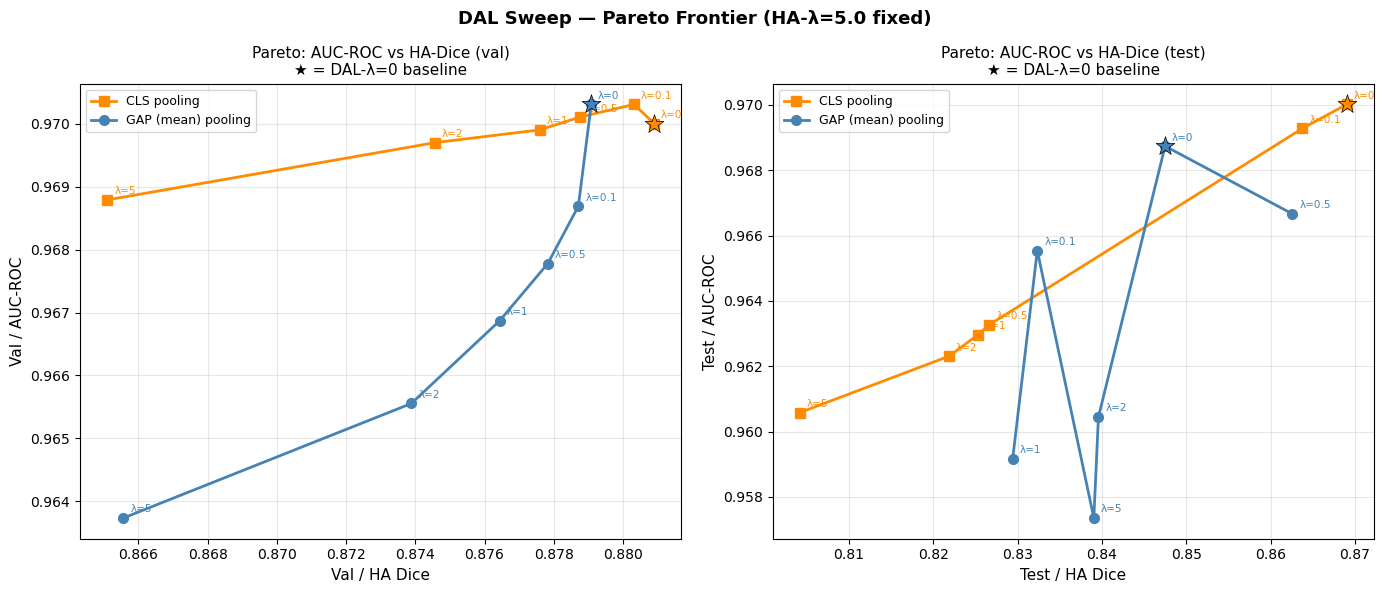

In [5]:
# ── CELL 8 — Helper
def save_or_show(fig, name):
    if SAVE_FIGURES:
        path = OUT_DIR / f"{OUT_PREFIX}_{name}.png"
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()

# ── CELL 9 — Pareto: AUC vs HA-Dice, coloured by pooling, annotated by DAL-lambda
def plot_dal_pareto(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, split in zip(axes, ["val", "test"]):
        x_col = f"{split}_ha_dice"
        y_col = f"{split}_auc_roc"
        for pooling, grp in df.groupby("pooling"):
            sub = grp[[x_col, y_col, "dal_lambda"]].dropna().sort_values(x_col)
            if sub.empty:
                continue
            ax.plot(
                sub[x_col], sub[y_col],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                linewidth=2, markersize=7,
                label=POOLING_LABELS[pooling], zorder=3,
            )
            # Mark DAL=0 baseline with star
            baseline = sub[sub["dal_lambda"] == 0.0]
            if not baseline.empty:
                ax.scatter(
                    baseline[x_col], baseline[y_col],
                    marker="*", s=200, color=COLORS[pooling],
                    zorder=5, edgecolors="black", linewidths=0.5,
                )
            for _, row in sub.iterrows():
                ax.annotate(
                    f"λ={row['dal_lambda']:.2g}",
                    (row[x_col], row[y_col]),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=7.5, color=COLORS[pooling],
                )
        ax.set_xlabel(f"{split.capitalize()} / HA Dice", fontsize=11)
        ax.set_ylabel(f"{split.capitalize()} / AUC-ROC", fontsize=11)
        ax.set_title(f"Pareto: AUC-ROC vs HA-Dice ({split})\n★ = DAL-λ=0 baseline", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    plt.suptitle("DAL Sweep — Pareto Frontier (HA-λ=5.0 fixed)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "pareto")

if not df.empty:
    plot_dal_pareto(df)

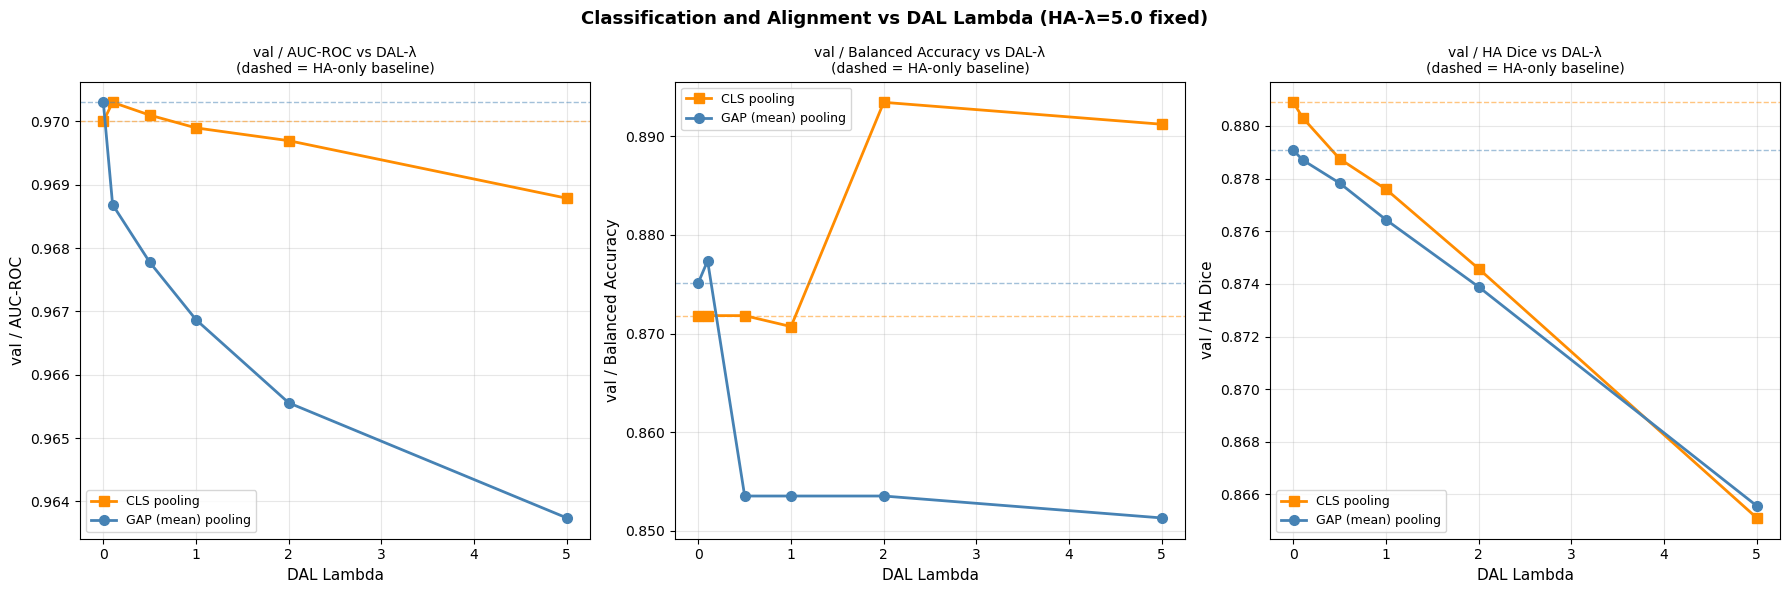

In [6]:
# ── CELL 10 — Classification metrics vs DAL-lambda
def plot_classification_vs_dal(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    metrics = [
        ("val_auc_roc",      "val / AUC-ROC",           axes[0]),
        ("val_balanced_acc", "val / Balanced Accuracy",  axes[1]),
        ("val_ha_dice",      "val / HA Dice",            axes[2]),
    ]
    for col, ylabel, ax in metrics:
        for pooling, grp in df.groupby("pooling"):
            sub = grp[grp[col].notna()].sort_values("dal_lambda")
            if sub.empty:
                continue
            ax.plot(
                sub["dal_lambda"], sub[col],
                marker=MARKERS[pooling], color=COLORS[pooling],
                linewidth=2, markersize=7, label=POOLING_LABELS[pooling],
            )
            # Baseline reference line at DAL=0
            baseline_val = sub.loc[sub["dal_lambda"] == 0.0, col]
            if not baseline_val.empty:
                ax.axhline(
                    baseline_val.values[0],
                    color=COLORS[pooling], linestyle="--",
                    linewidth=1, alpha=0.5,
                )
        ax.set_xlabel("DAL Lambda", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f"{ylabel} vs DAL-λ\n(dashed = HA-only baseline)", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    plt.suptitle("Classification and Alignment vs DAL Lambda (HA-λ=5.0 fixed)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "metrics_vs_dal_lambda")

if not df.empty:
    plot_classification_vs_dal(df)

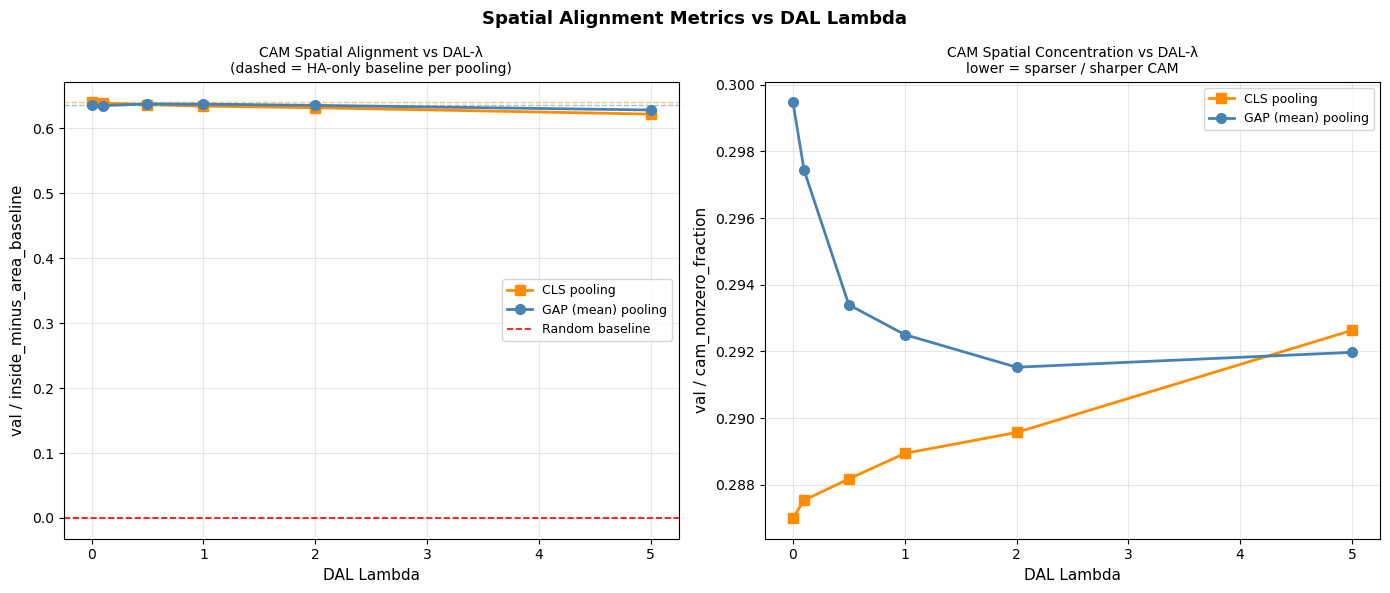

In [7]:
# ── CELL 11 — Alignment metrics vs DAL-lambda
def plot_alignment_vs_dal(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for pooling, grp in df.groupby("pooling"):
        sub_im = grp[grp["val_inside_minus"].notna()].sort_values("dal_lambda")
        if not sub_im.empty:
            axes[0].plot(
                sub_im["dal_lambda"], sub_im["val_inside_minus"],
                marker=MARKERS[pooling], color=COLORS[pooling],
                linewidth=2, markersize=7, label=POOLING_LABELS[pooling],
            )
            baseline = sub_im.loc[sub_im["dal_lambda"] == 0.0, "val_inside_minus"]
            if not baseline.empty:
                axes[0].axhline(baseline.values[0], color=COLORS[pooling],
                                linestyle="--", linewidth=1, alpha=0.5)

        sub_nz = grp[grp["val_cam_nz_frac"].notna()].sort_values("dal_lambda")
        if not sub_nz.empty:
            axes[1].plot(
                sub_nz["dal_lambda"], sub_nz["val_cam_nz_frac"],
                marker=MARKERS[pooling], color=COLORS[pooling],
                linewidth=2, markersize=7, label=POOLING_LABELS[pooling],
            )

    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.2, label="Random baseline")
    axes[0].set_xlabel("DAL Lambda", fontsize=11)
    axes[0].set_ylabel("val / inside_minus_area_baseline", fontsize=11)
    axes[0].set_title("CAM Spatial Alignment vs DAL-λ\n(dashed = HA-only baseline per pooling)", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("DAL Lambda", fontsize=11)
    axes[1].set_ylabel("val / cam_nonzero_fraction", fontsize=11)
    axes[1].set_title("CAM Spatial Concentration vs DAL-λ\nlower = sparser / sharper CAM", fontsize=10)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Spatial Alignment Metrics vs DAL Lambda", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "alignment_vs_dal_lambda")

if not df.empty:
    plot_alignment_vs_dal(df)

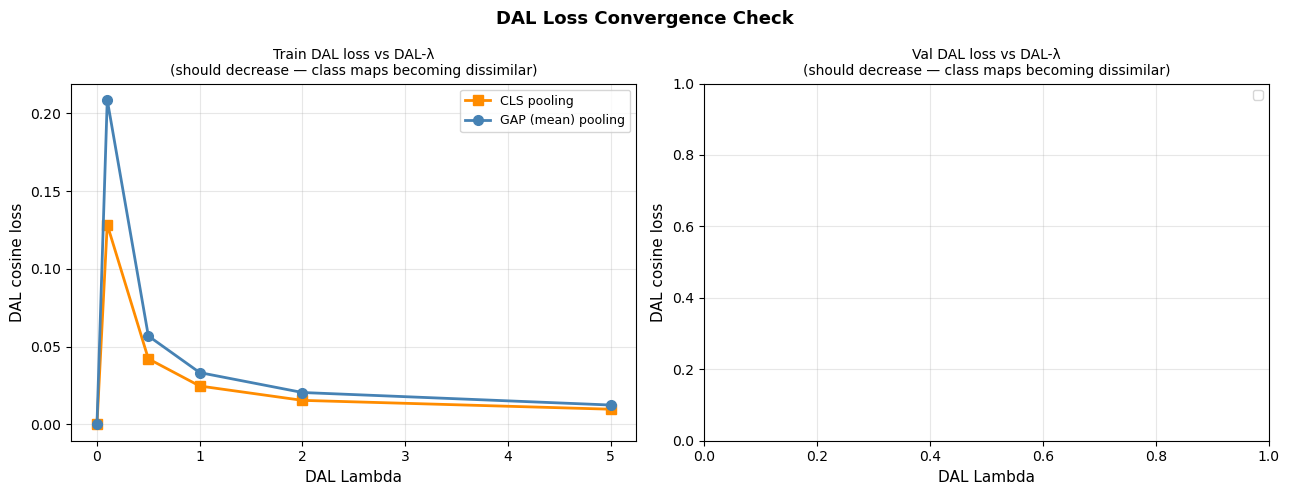

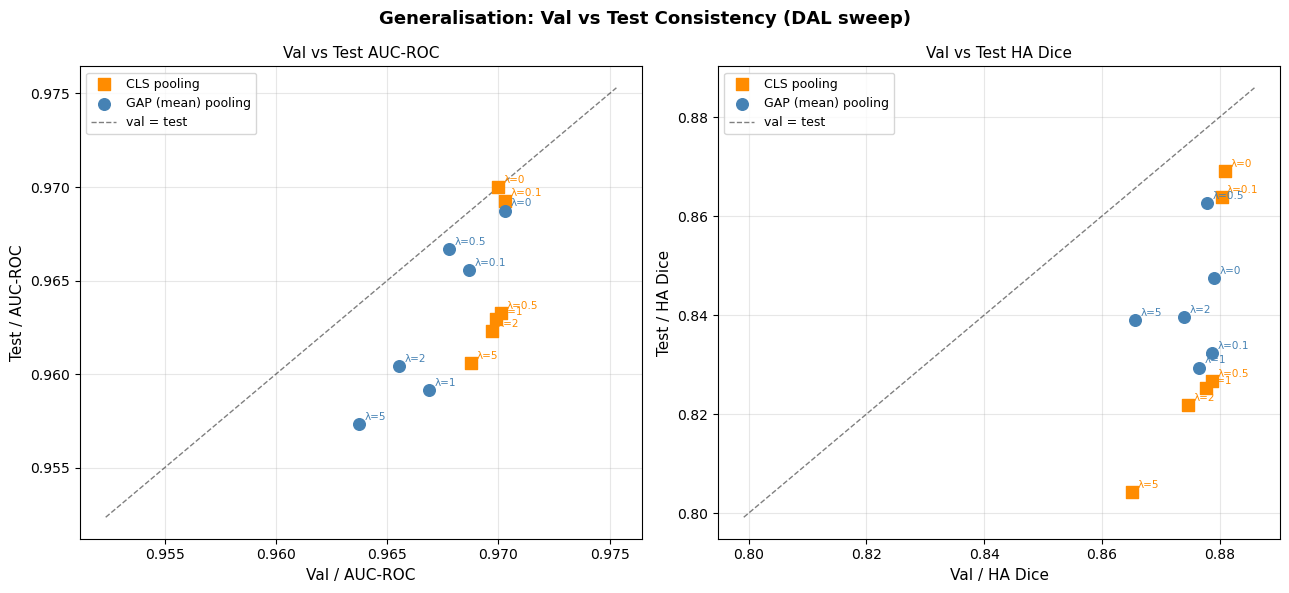

In [8]:
# ── CELL 12 — DAL loss vs DAL-lambda (confirms DAL is active and converging)
def plot_dal_loss_vs_lambda(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for pooling, grp in df.groupby("pooling"):
        for col, ax in [("train_dal_loss", axes[0]), ("val_dal_loss", axes[1])]:
            sub = grp[grp[col].notna()].sort_values("dal_lambda")
            if sub.empty:
                continue
            ax.plot(
                sub["dal_lambda"], sub[col],
                marker=MARKERS[pooling], color=COLORS[pooling],
                linewidth=2, markersize=7, label=POOLING_LABELS[pooling],
            )
    for ax, title in zip(axes, ["Train DAL loss vs DAL-λ", "Val DAL loss vs DAL-λ"]):
        ax.set_xlabel("DAL Lambda", fontsize=11)
        ax.set_ylabel("DAL cosine loss", fontsize=11)
        ax.set_title(title + "\n(should decrease — class maps becoming dissimilar)", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    plt.suptitle("DAL Loss Convergence Check", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "dal_loss_vs_lambda")

if not df.empty:
    plot_dal_loss_vs_lambda(df)

# ── CELL 13 — Val vs Test consistency
def plot_val_vs_test_dal(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    for ax, metric, label in [
        (axes[0], "auc_roc",  "AUC-ROC"),
        (axes[1], "ha_dice",  "HA Dice"),
    ]:
        val_col  = f"val_{metric}"
        test_col = f"test_{metric}"
        for pooling, grp in df.groupby("pooling"):
            sub = grp[[val_col, test_col, "dal_lambda"]].dropna()
            if sub.empty:
                continue
            ax.scatter(
                sub[val_col], sub[test_col],
                marker=MARKERS[pooling], color=COLORS[pooling],
                s=70, zorder=3, label=POOLING_LABELS[pooling],
            )
            for _, row in sub.iterrows():
                ax.annotate(
                    f"λ={row['dal_lambda']:.2g}",
                    (row[val_col], row[test_col]),
                    textcoords="offset points", xytext=(4, 3),
                    fontsize=7.5, color=COLORS[pooling],
                )
        all_vals = pd.concat([df[val_col], df[test_col]]).dropna()
        if not all_vals.empty:
            lo, hi = all_vals.min() - 0.005, all_vals.max() + 0.005
            ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.5, label="val = test")
        ax.set_xlabel(f"Val / {label}", fontsize=11)
        ax.set_ylabel(f"Test / {label}", fontsize=11)
        ax.set_title(f"Val vs Test {label}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    plt.suptitle("Generalisation: Val vs Test Consistency (DAL sweep)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "val_vs_test")

if not df.empty:
    plot_val_vs_test_dal(df)

In [9]:
# ── CELL 14 — Combined rank table (Pareto candidates)
if not df.empty:
    candidate_cols = [
        "run_name", "pooling", "dal_lambda",
        "val_auc_roc", "val_balanced_acc",
        "val_ha_dice", "val_inside_minus",
        "test_auc_roc", "test_ha_dice", "test_inside_minus",
    ]
    candidates = df[candidate_cols].copy()
    candidates["auc_rank"]      = candidates["val_auc_roc"].rank(ascending=False)
    candidates["align_rank"]    = candidates["val_inside_minus"].rank(ascending=False)
    candidates["combined_rank"] = candidates["auc_rank"] + candidates["align_rank"]
    candidates = candidates.sort_values("combined_rank")
    display(candidates)

,run_name,pooling,dal_lambda,val_auc_roc,val_balanced_acc,val_ha_dice,val_inside_minus,test_auc_roc,test_ha_dice,test_inside_minus,auc_rank,align_rank,combined_rank
1,sweep_dal__cls__hal5__dall0p1__ep10__lr1e5,cls,0.1,0.970303,0.871818,0.880317,0.638955,0.969280,0.863773,0.612342,1.0,2.0,3.0
0,sweep_dal__cls__hal5__dall0p0__ep10__lr1e5,cls,0.0,0.970000,0.871818,0.880899,0.640165,0.970017,0.869028,0.617233,4.0,1.0,5.0
2,sweep_dal__cls__hal5__dall0p5__ep10__lr1e5,cls,0.5,0.970101,0.871818,0.878751,0.636676,0.963272,0.826638,0.569052,3.0,5.0,8.0
6,sweep_dal__gap__hal5__dall0p0__ep10__lr1e5,gap,0.0,0.970303,0.875152,0.879082,0.635400,0.968740,0.847491,0.595455,2.0,7.0,9.0
8,sweep_dal__gap__hal5__dall0p5__ep10__lr1e5,gap,0.5,0.967778,0.853535,0.877828,0.637794,0.966667,0.862580,0.610248,9.0,3.0,12.0
3,sweep_dal__cls__hal5__dall1p0__ep10__lr1e5,cls,1.0,0.969899,0.870707,0.877596,0.634274,0.962956,0.825249,0.567656,5.0,9.0,14.0
9,sweep_dal__gap__hal5__dall1p0__ep10__lr1e5,gap,1.0,0.966869,0.853535,0.876436,0.637427,0.959171,0.829413,0.570571,10.0,4.0,14.0
4,sweep_dal__cls__hal5__dall2p0__ep10__lr1e5,cls,2.0,0.969697,0.893434,0.874575,0.631839,0.962310,0.821880,0.565187,6.0,10.0,16.0
7,sweep_dal__gap__hal5__dall0p1__ep10__lr1e5,gap,0.1,0.968687,0.877374,0.878710,0.635028,0.965540,0.832331,0.572074,8.0,8.0,16.0
10,sweep_dal__gap__hal5__dall2p0__ep10__lr1e5,gap,2.0,0.965556,0.853535,0.873885,0.635467,0.960448,0.839585,0.593707,11.0,6.0,17.0


In [10]:
# ── CELL 15 — Pareto filter (max 2% AUC drop, best alignment)
if not df.empty:
    max_auc = df["val_auc_roc"].max()
    allowed_drop = 0.02
    pareto = (
        df[df["val_auc_roc"] >= max_auc - allowed_drop]
        .copy()
        .sort_values(["val_inside_minus", "val_ha_dice"], ascending=False)
    )
    print(f"Best val AUC across all DAL runs: {max_auc:.4f}")
    print(f"Keeping models with val AUC >= {max_auc - allowed_drop:.4f}")
    display(pareto[[
        "run_name", "pooling", "dal_lambda",
        "val_auc_roc", "val_balanced_acc",
        "val_ha_dice", "val_inside_minus",
        "test_auc_roc", "test_ha_dice", "test_inside_minus",
    ]])

Best val AUC across all DAL runs: 0.9703
Keeping models with val AUC >= 0.9503


,run_name,pooling,dal_lambda,val_auc_roc,val_balanced_acc,val_ha_dice,val_inside_minus,test_auc_roc,test_ha_dice,test_inside_minus
0,sweep_dal__cls__hal5__dall0p0__ep10__lr1e5,cls,0.0,0.970000,0.871818,0.880899,0.640165,0.970017,0.869028,0.617233
1,sweep_dal__cls__hal5__dall0p1__ep10__lr1e5,cls,0.1,0.970303,0.871818,0.880317,0.638955,0.969280,0.863773,0.612342
8,sweep_dal__gap__hal5__dall0p5__ep10__lr1e5,gap,0.5,0.967778,0.853535,0.877828,0.637794,0.966667,0.862580,0.610248
9,sweep_dal__gap__hal5__dall1p0__ep10__lr1e5,gap,1.0,0.966869,0.853535,0.876436,0.637427,0.959171,0.829413,0.570571
2,sweep_dal__cls__hal5__dall0p5__ep10__lr1e5,cls,0.5,0.970101,0.871818,0.878751,0.636676,0.963272,0.826638,0.569052
10,sweep_dal__gap__hal5__dall2p0__ep10__lr1e5,gap,2.0,0.965556,0.853535,0.873885,0.635467,0.960448,0.839585,0.593707
6,sweep_dal__gap__hal5__dall0p0__ep10__lr1e5,gap,0.0,0.970303,0.875152,0.879082,0.635400,0.968740,0.847491,0.595455
7,sweep_dal__gap__hal5__dall0p1__ep10__lr1e5,gap,0.1,0.968687,0.877374,0.878710,0.635028,0.965540,0.832331,0.572074
3,sweep_dal__cls__hal5__dall1p0__ep10__lr1e5,cls,1.0,0.969899,0.870707,0.877596,0.634274,0.962956,0.825249,0.567656
4,sweep_dal__cls__hal5__dall2p0__ep10__lr1e5,cls,2.0,0.969697,0.893434,0.874575,0.631839,0.962310,0.821880,0.565187
